In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import datasets
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score

import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(return_X_y=True)

X, y = cancer[0], cancer[1]

In [3]:
#Import standardscaler
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

In [4]:
tsne_embeddings = TSNE(n_components=2,
                       perplexity=30,
                       random_state=11).fit_transform(X_scaled)

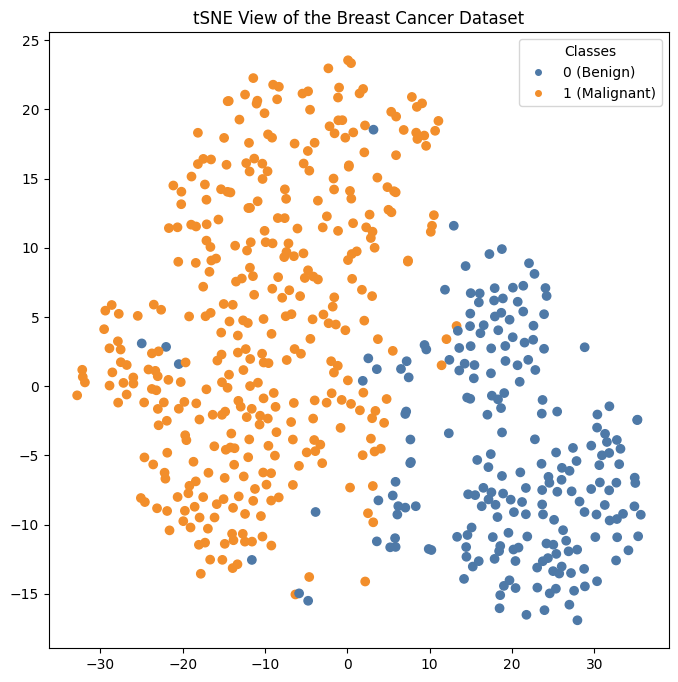

In [25]:
from matplotlib.colors import ListedColormap

fig = plt.figure(figsize = (8,8))

ax = fig.add_subplot(1,1,1) 
ax.set_title('tSNE View of the Breast Cancer Dataset', fontsize = 12)

colors = ['#4E79A7', '#F28E2B']  
cmap = ListedColormap(colors)

classes = [0, 1]

ax.scatter(tsne_embeddings[:,0],
           tsne_embeddings[:,1],
           c = y,
           cmap=cmap)

# large_PAC = [  4, 130,  78,  95]
# texts = ['a', 'b', 'c', 'd']

# for i in range(len(texts)):
#     ax.text(tsne_embeddings[large_PAC[i],0]+0.2,
#            tsne_embeddings[large_PAC[i],1],
#            texts[i])



handles = [plt.Line2D([0], [0], marker='o', color=cmap(i / len(classes)), 
                      linestyle='', markersize=4) for i in classes]

# Add legend to the plot
ax.legend(handles, ['0 (Benign)', '1 (Malignant)'], title='Classes')
plt.show()

Prediction with Random Forest

In [6]:
indices = np.arange(X.shape[0])

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X, y, indices, test_size=0.33,random_state=1)

In [7]:
clf = LinearDiscriminantAnalysis()

clf.fit(X_train,y_train)

LinearDiscriminantAnalysis()

In [8]:
scores=cross_val_score(clf,X_train,y_train,cv=5)
scores
print("Mean: %0.2f ; Standard Dev.: %0.2f)" % (scores.mean(), scores.std()))

Mean: 0.96 ; Standard Dev.: 0.03)


Searching for 14 nearest neighbors for 188 points. This could take some time!
Nearest neighbor search complete !
(array([  7,  38,  72,  76,  77, 139, 140]),)


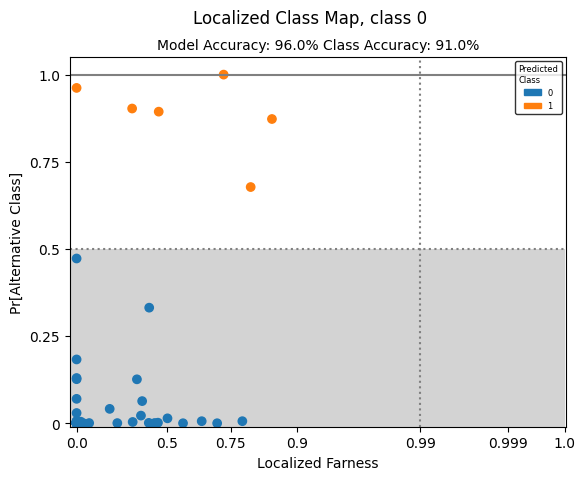

In [23]:
# source localized classmap
exec(open('localized_classmap.py').read())

k = int(np.round(np.sqrt(X_test.shape[0]),0))

# class 0
plotExplanations(model=clf,
                 X=X_test,
                 y=y_test,
                 k=k,
                 cl=0,
                 annotate=False,
                 pytorch=False)

Searching for 14 nearest neighbors for 188 points. This could take some time!
Nearest neighbor search complete !
(array([  7,  38,  72,  76,  77, 139, 140]),)


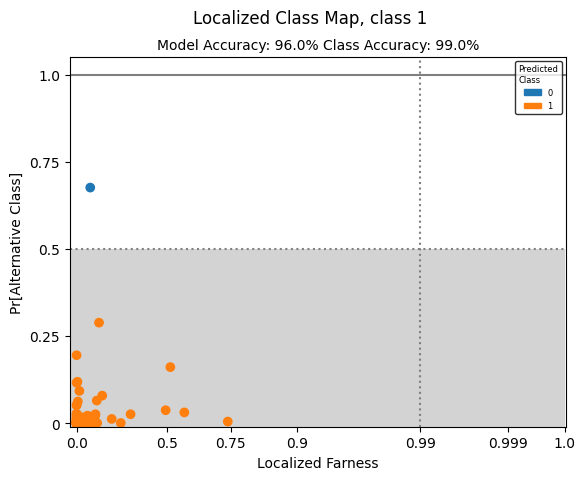

In [18]:
# class 1
plotExplanations(model=clf,
                 X=X_test,
                 y=y_test,
                 k=k,
                 cl=1,
                 annotate=True,
                 pytorch=False)